In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, classification_report
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, Input, Dropout, BatchNormalization, Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings
import joblib
import os
warnings.filterwarnings('ignore')

# 设置随机种子
np.random.seed(42)
tf.random.set_seed(42)
from sklearn.metrics import confusion_matrix
from sklearn.inspection import permutation_importance

class ModelVisualizer:
    def __init__(self, predictor, test_data, feature_names):
        """
        初始化可视化分析器。
        
        参数:
            predictor (EnvironmentalPredictor): 训练好的 EnvironmentalPredictor 实例。
            test_data (tuple): 包含 (X_test, y_test_dict) 的元组。
            feature_names (list): 特征名称列表。
        """
        if not predictor.is_fitted:
            raise ValueError("传入的 predictor 必须是已经训练好的模型。")
            
        self.predictor = predictor
        self.model = predictor.model
        self.X_test, self.y_test = test_data
        self.feature_names = feature_names
        self.use_sequences = predictor.use_sequences
        
        # 获取预测结果
        print("正在生成用于可视化的预测结果...")
        self.predictions = self.model.predict(self.X_test)
        
        # 解码预测和真实标签
        self.weather_pred_labels = np.argmax(self.predictions[0], axis=1)
        self.weather_true_labels = self.y_test['weather_output']
        self.weather_class_names = self.predictor.weather_encoder.classes_
        
        self.wind_pred_labels = np.argmax(self.predictions[1], axis=1)
        self.wind_true_labels = self.y_test['wind_output']
        
        self.rain_pred = self.predictions[2].flatten()
        self.rain_true = self.y_test['rain_output']
        print("初始化完成，可以开始绘图。")

    def plot_training_history(self, history):
        """绘制训练历史曲线"""
        print("\n--- 1. 绘制训练过程历史 ---")
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle('模型训练过程分析', fontsize=20)
        
        # 总损失
        axes[0, 0].plot(history.history['loss'], label='训练损失 (Training Loss)')
        axes[0, 0].plot(history.history['val_loss'], label='验证损失 (Validation Loss)')
        axes[0, 0].set_title('整体损失函数变化')
        axes[0, 0].set_xlabel('轮次 (Epoch)')
        axes[0, 0].set_ylabel('损失 (Loss)')
        axes[0, 0].legend()
        axes[0, 0].grid(True)
        
        # 天气预测准确率
        axes[0, 1].plot(history.history['weather_output_accuracy'], label='训练准确率')
        axes[0, 1].plot(history.history['val_weather_output_accuracy'], label='验证准确率')
        axes[0, 1].set_title('天气预测准确率')
        axes[0, 1].set_xlabel('轮次 (Epoch)')
        axes[0, 1].set_ylabel('准确率 (Accuracy)')
        axes[0, 1].legend()
        axes[0, 1].grid(True)
        
        # 风力预测准确率
        axes[1, 0].plot(history.history['wind_output_accuracy'], label='训练准确率')
        axes[1, 0].plot(history.history['val_wind_output_accuracy'], label='验证准确率')
        axes[1, 0].set_title('风力预测准确率')
        axes[1, 0].set_xlabel('轮次 (Epoch)')
        axes[1, 0].set_ylabel('准确率 (Accuracy)')
        axes[1, 0].legend()
        axes[1, 0].grid(True)
        
        # 降水预测MAE
        axes[1, 1].plot(history.history['rain_output_mae'], label='训练 MAE')
        axes[1, 1].plot(history.history['val_rain_output_mae'], label='验证 MAE')
        axes[1, 1].set_title('降水预测平均绝对误差 (MAE)')
        axes[1, 1].set_xlabel('轮次 (Epoch)')
        axes[1, 1].set_ylabel('MAE')
        axes[1, 1].legend()
        axes[1, 1].grid(True)
        
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

    def plot_classification_analysis(self, task_name, true_labels, pred_labels, class_names):
        """
        为分类任务（天气/风力）绘制混淆矩阵和分类报告图。
        """
        print(f"\n--- 2. {task_name} 预测性能分析 ---")
        fig, axes = plt.subplots(1, 2, figsize=(20, 8))
        fig.suptitle(f'{task_name} 预测性能分析', fontsize=20)

        # 2a. 混淆矩阵
        cm = confusion_matrix(true_labels, pred_labels)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=class_names, yticklabels=class_names, ax=axes[0])
        axes[0].set_title('混淆矩阵 (Confusion Matrix)')
        axes[0].set_xlabel('预测标签 (Predicted Label)')
        axes[0].set_ylabel('真实标签 (True Label)')

        # 2b. 分类报告可视化
        report = classification_report(true_labels, pred_labels, 
                                       target_names=class_names, output_dict=True)
        report_df = pd.DataFrame(report).transpose()
        report_df.drop(['accuracy', 'macro avg', 'weighted avg'], inplace=True)
        report_df['f1-score'].plot(kind='bar', ax=axes[1], color=['#66c2a5', '#fc8d62', '#8da0cb'])
        axes[1].set_title('各类别 F1-Score 对比')
        axes[1].set_xlabel('类别')
        axes[1].set_ylabel('F1-Score')
        axes[1].tick_params(axis='x', rotation=45)
        axes[1].grid(axis='y')

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()
        
        # 打印详细报告以供参考
        print(f"\n{task_name} 分类报告详情:")
        print(classification_report(true_labels, pred_labels, target_names=class_names))

    def plot_regression_analysis(self):
        """为回归任务（降水）绘制分析图。"""
        print("\n--- 3. 降水强度预测性能分析 ---")
        fig, axes = plt.subplots(1, 2, figsize=(16, 7))
        fig.suptitle('降水强度预测性能分析', fontsize=20)

        # 3a. 真实值 vs 预测值
        axes[0].scatter(self.rain_true, self.rain_pred, alpha=0.5, edgecolors='k')
        axes[0].plot([self.rain_true.min(), self.rain_true.max()], 
                     [self.rain_true.min(), self.rain_true.max()], 
                     'r--', lw=2, label='理想情况 (y=x)')
        axes[0].set_title('真实值 vs. 预测值')
        axes[0].set_xlabel('真实降水强度 (True Values)')
        axes[0].set_ylabel('预测降水强度 (Predicted Values)')
        axes[0].legend()
        axes[0].grid(True)

        # 3b. 残差图
        residuals = self.rain_true - self.rain_pred
        sns.residplot(x=self.rain_pred, y=residuals, lowess=True, 
                      ax=axes[1], scatter_kws={'alpha': 0.5},
                      line_kws={'color': 'red', 'lw': 2, 'label': '趋势线'})
        axes[1].set_title('残差图 (Residuals Plot)')
        axes[1].set_xlabel('预测降水强度 (Predicted Values)')
        axes[1].set_ylabel('残差 (Residuals = True - Predicted)')
        axes[1].grid(True)
        axes[1].legend()

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

    def plot_permutation_feature_importance(self):
        """
        计算并绘制置换特征重要性。
        - 对于非时序数据(2D)，使用 sklearn 的 permutation_importance。
        - 对于时序数据(3D)，手动实现置换重要性计算。
        """
        print("\n--- 4. 特征重要性分析 (Permutation Importance) ---")

        # --- (关键修正开始) ---
        
        # 检查是否为时序数据
        if self.use_sequences:
            print("检测到序列模型(3D数据)，将使用手动实现的置换重要性分析。")
            print("注意: 此过程可能会非常耗时。")
            
            # 1. 手动为3D数据实现置换重要性
            
            # 计算基准性能得分 (使用总损失)
            print("正在计算基准性能...")
            baseline_loss = self.model.evaluate(self.X_test, self.y_test, verbose=0)
            baseline_score = -baseline_loss[0] # 分数越高越好，所以取负损失
            print(f"基准得分 (负总损失): {baseline_score:.4f}")

            importances = []
            # 获取特征数量 (在最后一个维度)
            n_features = self.X_test.shape[2]

            # 2. 遍历每一个特征
            for i in range(n_features):
                feature_name = self.feature_names[i]
                print(f"正在置换特征 {i+1}/{n_features}: {feature_name}...")
                
                # 创建数据副本
                X_test_permuted = self.X_test.copy()
                
                # 在所有样本和时间步上，只打乱当前特征i
                # np.random.permutation 会创建一个打乱后的一维数组
                original_feature_slice = X_test_permuted[:, :, i]
                permuted_slice = np.random.permutation(original_feature_slice.flatten()).reshape(original_feature_slice.shape)
                X_test_permuted[:, :, i] = permuted_slice

                # 3. 在打乱后的数据上评估性能
                permuted_loss = self.model.evaluate(X_test_permuted, self.y_test, verbose=0)
                permuted_score = -permuted_loss[0]
                
                # 4. 计算重要性并存储
                importance = baseline_score - permuted_score
                importances.append(importance)
            
            # 将手动计算的结果整理成与 sklearn 版本相似的格式
            importances_mean = np.array(importances)
            perm_sorted_idx = importances_mean.argsort()

        else:
            # 对于非时序数据(2D)，使用我们之前实现的基于包装器的方案
            print("检测到非序列模型(2D数据)，将使用 scikit-learn 的 permutation_importance。")

            class KerasSklearnWrapper:
                def __init__(self, model): self.model = model
                def fit(self, X, y): pass
                def predict(self, X): return self.model.predict(X)

            def custom_scorer(estimator, X, y):
                loss = estimator.model.evaluate(X, y, verbose=0)
                return -loss[0]

            sklearn_compatible_estimator = KerasSklearnWrapper(self.model)
            
            print("正在计算置换重要性，这可能需要一些时间...")
            result = permutation_importance(
                estimator=sklearn_compatible_estimator,
                X=self.X_test, 
                y=self.y_test,
                scoring=custom_scorer,
                n_repeats=10,
                random_state=42,
                n_jobs=-1
            )
            importances_mean = result.importances_mean
            perm_sorted_idx = importances_mean.argsort()

        # --- (关键修正结束) ---

        # 整理并展示结果 (这部分代码无需改变，因为它依赖于 perm_sorted_idx 和 importances_mean)
        importance_df = pd.DataFrame(
            data={'feature': np.array(self.feature_names)[perm_sorted_idx],
                  'importance': importances_mean[perm_sorted_idx]}
        )
        
        plt.figure(figsize=(12, 10))
        plt.barh(importance_df['feature'], importance_df['importance'], color='#8da0cb')
        plt.title('置换特征重要性 (Permutation Feature Importance)')
        plt.xlabel('重要性 (模型性能下降幅度)')
        plt.grid(axis='x')
        plt.tight_layout()
        plt.show()

class EnvironmentalPredictor:
    def __init__(self):
        self.scaler_features = StandardScaler()
        self.scaler_continuous_targets = StandardScaler()
        self.weather_encoder = None
        self.is_fitted = False
    def save_model(self, model_path='saved_model'):
        """保存模型及预处理器"""
        if not self.is_fitted:
            raise ValueError("模型尚未训练，无法保存。")

        os.makedirs(model_path, exist_ok=True)
        
        # 保存 Keras 模型
        self.model.save(os.path.join(model_path, 'model.h5'))

        # 保存缩放器和编码器
        joblib.dump(self.scaler_features, os.path.join(model_path, 'scaler_features.pkl'))
        joblib.dump(self.weather_encoder, os.path.join(model_path, 'weather_encoder.pkl'))

        # 保存元信息
        with open(os.path.join(model_path, 'meta_info.txt'), 'w') as f:
            f.write(f"use_sequences={self.use_sequences}\n")
            if self.use_sequences:
                f.write(f"sequence_length={self.sequence_length}\n")
        
        print(f"模型和预处理器已保存至：{model_path}")
    def load_model(self, model_path='saved_model'):
        """加载模型及预处理器"""
        if not os.path.exists(model_path):
            raise FileNotFoundError(f"模型路径不存在: {model_path}")

        # 加载 Keras 模型
        self.model = tf.keras.models.load_model(os.path.join(model_path, 'model.h5'))

        # 加载缩放器和编码器
        self.scaler_features = joblib.load(os.path.join(model_path, 'scaler_features.pkl'))
        self.weather_encoder = joblib.load(os.path.join(model_path, 'weather_encoder.pkl'))

        # 读取元信息
        meta_info_path = os.path.join(model_path, 'meta_info.txt')
        if os.path.exists(meta_info_path):
            with open(meta_info_path, 'r') as f:
                lines = f.readlines()
                for line in lines:
                    if line.startswith("use_sequences="):
                        self.use_sequences = line.strip().split('=')[1].lower() == 'true'
                    elif line.startswith("sequence_length="):
                        self.sequence_length = int(line.strip().split('=')[1])
        
        self.is_fitted = True
        print(f"模型和预处理器已从 {model_path} 成功加载。")

    def load_and_preprocess_data(self, file_path):
        """加载和预处理数据"""
        # 读取数据
        columns = ['纬度', '经度', 'SO2', 'NO2', 'PM10', '污染程度', '日期', '时间段', 
                  '气温', '风向编码', '风力编码', '降水强度', '天气_多云', '天气_晴', 
                  '天气_阴', '天气_雨', '天气_雪', '天气_雾霾沙尘']
        
        data = pd.read_csv(file_path)
        
        # 处理日期
        data['日期'] = pd.to_datetime(data['日期'])
        data['年'] = data['日期'].dt.year
        data['月'] = data['日期'].dt.month
        data['日'] = data['日期'].dt.day
        data['星期'] = data['日期'].dt.dayofweek
        
        # 创建天气标签（从one-hot转换）
        weather_cols = ['天气_多云', '天气_晴', '天气_阴', '天气_雨', '天气_雪', '天气_雾霾沙尘']
        data['天气类别'] = data[weather_cols].idxmax(axis=1).str.replace('天气_', '')
        
        # 特征工程：添加时间特征
        data['sin_月'] = np.sin(2 * np.pi * data['月'] / 12)
        data['cos_月'] = np.cos(2 * np.pi * data['月'] / 12)
        data['sin_日'] = np.sin(2 * np.pi * data['日'] / 31)
        data['cos_日'] = np.cos(2 * np.pi * data['日'] / 31)
        data['sin_星期'] = np.sin(2 * np.pi * data['星期'] / 7)
        data['cos_星期'] = np.cos(2 * np.pi * data['星期'] / 7)
        
        # 添加空间特征
        data['位置hash'] = data['纬度'].astype(str) + '_' + data['经度'].astype(str)
        
        # 添加污染物综合指标
        data['污染物总和'] = data['SO2'] + data['NO2'] + data['PM10']
        data['污染物比例_SO2'] = data['SO2'] / (data['污染物总和'] + 1e-8)
        data['污染物比例_NO2'] = data['NO2'] / (data['污染物总和'] + 1e-8)
        data['污染物比例_PM10'] = data['PM10'] / (data['污染物总和'] + 1e-8)
        
        return data
    
    def create_sequences(self, data, sequence_length=24):
        """创建时序序列数据"""
        # 按位置分组
        grouped = data.groupby('位置hash')
        
        sequences_X = []
        sequences_y_weather = []
        sequences_y_wind = []
        sequences_y_rain = []
        
        for location, group in grouped:
            if len(group) < sequence_length + 1:
                continue
                
            group_sorted = group.sort_values(['日期', '时间段'])
            
            for i in range(len(group_sorted) - sequence_length):
                # 输入特征序列
                seq_features = ['纬度', '经度', 'SO2', 'NO2', 'PM10', '污染程度', 
                              '时间段', '气温', 'sin_月', 'cos_月', 'sin_日', 'cos_日', 
                              'sin_星期', 'cos_星期', '污染物总和', '污染物比例_SO2', 
                              '污染物比例_NO2', '污染物比例_PM10']
                
                seq_X = group_sorted[seq_features].iloc[i:i+sequence_length].values
                
                # 目标变量（预测下一个时间点）
                target_row = group_sorted.iloc[i+sequence_length]
                
                sequences_X.append(seq_X)
                sequences_y_weather.append(target_row['天气类别'])
                sequences_y_wind.append(target_row['风力编码'])
                sequences_y_rain.append(target_row['降水强度'])
        
        return np.array(sequences_X), np.array(sequences_y_weather), np.array(sequences_y_wind), np.array(sequences_y_rain)
    
    def prepare_non_sequential_data(self, data):
        """准备非时序数据"""
        # 输入特征
        feature_cols = ['纬度', '经度', 'SO2', 'NO2', 'PM10', '污染程度', 
                       '时间段', '气温', 'sin_月', 'cos_月', 'sin_日', 'cos_日', 
                       'sin_星期', 'cos_星期', '污染物总和', '污染物比例_SO2', 
                       '污染物比例_NO2', '污染物比例_PM10']
        
        X = data[feature_cols].values
        y_weather = data['天气类别'].values
        y_wind = data['风力编码'].values
        y_rain = data['降水强度'].values
        
        return X, y_weather, y_wind, y_rain
    
    def build_lstm_model(self, input_shape, n_weather_classes, max_wind, max_rain):
        """构建LSTM多输出模型"""
        # 输入层
        input_layer = Input(shape=input_shape)
        
        # LSTM层
        lstm1 = LSTM(128, return_sequences=True, dropout=0.2)(input_layer)
        lstm2 = LSTM(64, dropout=0.2)(lstm1)
        
        # 批归一化
        bn = BatchNormalization()(lstm2)
        
        # 共享的全连接层
        shared_dense = Dense(64, activation='relu')(bn)
        shared_dense = Dropout(0.3)(shared_dense)
        
        # 天气预测分支
        weather_branch = Dense(32, activation='relu', name='weather_dense')(shared_dense)
        weather_output = Dense(n_weather_classes, activation='softmax', name='weather_output')(weather_branch)
        
        # 风力预测分支
        wind_branch = Dense(32, activation='relu', name='wind_dense')(shared_dense)
        wind_output = Dense(max_wind + 1, activation='softmax', name='wind_output')(wind_branch)
        
        # 降水预测分支
        rain_branch = Dense(32, activation='relu', name='rain_dense')(shared_dense)
        rain_output = Dense(1, activation='linear', name='rain_output')(rain_branch)
        
        # 构建模型
        model = Model(inputs=input_layer, 
                     outputs=[weather_output, wind_output, rain_output])
        
        return model
    
    def build_dense_model(self, input_shape, n_weather_classes, max_wind, max_rain):
        """构建全连接多输出模型"""
        # 输入层
        input_layer = Input(shape=(input_shape,))
        
        # 隐藏层
        dense1 = Dense(256, activation='relu')(input_layer)
        dense1 = BatchNormalization()(dense1)
        dense1 = Dropout(0.3)(dense1)
        
        dense2 = Dense(128, activation='relu')(dense1)
        dense2 = BatchNormalization()(dense2)
        dense2 = Dropout(0.3)(dense2)
        
        dense3 = Dense(64, activation='relu')(dense2)
        dense3 = Dropout(0.2)(dense3)
        
        # 天气预测分支
        weather_branch = Dense(32, activation='relu')(dense3)
        weather_output = Dense(n_weather_classes, activation='softmax', name='weather_output')(weather_branch)
        
        # 风力预测分支
        wind_branch = Dense(32, activation='relu')(dense3)
        wind_output = Dense(max_wind + 1, activation='softmax', name='wind_output')(wind_branch)
        
        # 降水预测分支
        rain_branch = Dense(32, activation='relu')(dense3)
        rain_output = Dense(1, activation='linear', name='rain_output')(rain_branch)
        
        # 构建模型
        model = Model(inputs=input_layer, 
                     outputs=[weather_output, wind_output, rain_output])
        
        return model
    
    def train_models(self, data, use_sequences=True, sequence_length=24):
        """训练模型"""
        print("开始数据预处理...")
        
        # 编码器准备
        from sklearn.preprocessing import LabelEncoder
        self.weather_encoder = LabelEncoder()
        weather_encoded = self.weather_encoder.fit_transform(data['天气类别'])
        
        if use_sequences:
            print("创建时序序列...")
            X, y_weather, y_wind, y_rain = self.create_sequences(data, sequence_length)
            if len(X) == 0:
                print("序列数据不足，切换到非时序模式...")
                use_sequences = False
        
        if not use_sequences:
            print("使用非时序数据...")
            X, y_weather, y_wind, y_rain = self.prepare_non_sequential_data(data)
            
        # 编码目标变量
        y_weather_encoded = self.weather_encoder.transform(y_weather)
        
        # 标准化特征
        if use_sequences:
            # 对于序列数据，需要重塑后标准化
            X_reshaped = X.reshape(-1, X.shape[-1])
            X_scaled_reshaped = self.scaler_features.fit_transform(X_reshaped)
            X_scaled = X_scaled_reshaped.reshape(X.shape)
        else:
            X_scaled = self.scaler_features.fit_transform(X)
        
        # 划分训练测试集
        if use_sequences:
            X_train, X_test, y_weather_train, y_weather_test, y_wind_train, y_wind_test, y_rain_train, y_rain_test = \
                train_test_split(X_scaled, y_weather_encoded, y_wind, y_rain, test_size=0.2, random_state=42)
        else:
            X_train, X_test, y_weather_train, y_weather_test, y_wind_train, y_wind_test, y_rain_train, y_rain_test = \
                train_test_split(X_scaled, y_weather_encoded, y_wind, y_rain, test_size=0.2, random_state=42)
        
        # 获取类别数量
        n_weather_classes = len(self.weather_encoder.classes_)
        max_wind = int(max(y_wind))
        max_rain = int(max(y_rain))
        
        print(f"天气类别数: {n_weather_classes}")
        print(f"最大风力: {max_wind}")
        print(f"最大降水强度: {max_rain}")
        
        # 构建模型
        if use_sequences:
            print("构建LSTM模型...")
            model = self.build_lstm_model(X_train.shape[1:], n_weather_classes, max_wind, max_rain)
        else:
            print("构建全连接模型...")
            model = self.build_dense_model(X_train.shape[1], n_weather_classes, max_wind, max_rain)
        
        # 编译模型
        model.compile(
            optimizer=Adam(learning_rate=0.001),
            loss={
                'weather_output': 'sparse_categorical_crossentropy',
                'wind_output': 'sparse_categorical_crossentropy',
                'rain_output': 'mse'
            },
            loss_weights={
                'weather_output': 1.0,
                'wind_output': 1.0,
                'rain_output': 0.5
            },
            metrics={
                'weather_output': 'accuracy',
                'wind_output': 'accuracy',
                'rain_output': 'mae'
            }
        )
        
        print("模型结构:")
        model.summary()
        
        # 回调函数
        callbacks = [
            EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
        ]
        
        # 训练模型
        print("开始训练...")
        history = model.fit(
            X_train,
            {
                'weather_output': y_weather_train,
                'wind_output': y_wind_train,
                'rain_output': y_rain_train
            },
            validation_data=(
                X_test,
                {
                    'weather_output': y_weather_test,
                    'wind_output': y_wind_test,
                    'rain_output': y_rain_test
                }
            ),
            epochs=100,
            batch_size=32,
            callbacks=callbacks,
            verbose=1
        )
        
        # 评估模型
        print("\n模型评估:")
        predictions = model.predict(X_test)
        
        # 天气预测评估
        weather_pred = np.argmax(predictions[0], axis=1)
        weather_acc = accuracy_score(y_weather_test, weather_pred)
        print(f"天气预测准确率: {weather_acc:.4f}")
        
        # 风力预测评估
        wind_pred = np.argmax(predictions[1], axis=1)
        wind_acc = accuracy_score(y_wind_test, wind_pred)
        print(f"风力预测准确率: {wind_acc:.4f}")
        
        # 降水预测评估
        rain_pred = predictions[2].flatten()
        rain_mse = mean_squared_error(y_rain_test, rain_pred)
        rain_mae = mean_absolute_error(y_rain_test, rain_pred)
        print(f"降水预测 MSE: {rain_mse:.4f}")
        print(f"降水预测 MAE: {rain_mae:.4f}")
        
        # 详细分类报告
        print("\n天气预测详细报告:")
        print(classification_report(y_weather_test, weather_pred, 
                                  target_names=self.weather_encoder.classes_))
        
        self.model = model
        self.is_fitted = True
        self.use_sequences = use_sequences
        self.sequence_length = sequence_length if use_sequences else None
        
        y_test_dict = {
            'weather_output': y_weather_test,
            'wind_output': y_wind_test,
            'rain_output': y_rain_test
            }
        feature_cols = ['纬度', '经度', 'SO2', 'NO2', 'PM10', '污染程度', 
                '时间段', '气温', 'sin_月', 'cos_月', 'sin_日', 'cos_日', 
                'sin_星期', 'cos_星期', '污染物总和', '污染物比例_SO2', 
                '污染物比例_NO2', '污染物比例_PM10']
        
        return history, (X_test, y_test_dict), feature_cols
    
    def predict(self, input_data):
        """进行预测"""
        if not self.is_fitted:
            raise ValueError("模型尚未训练，请先调用train_models方法")
        
        # 标准化输入数据
        if self.use_sequences:
            input_reshaped = input_data.reshape(-1, input_data.shape[-1])
            input_scaled_reshaped = self.scaler_features.transform(input_reshaped)
            input_scaled = input_scaled_reshaped.reshape(input_data.shape)
        else:
            input_scaled = self.scaler_features.transform(input_data)
        
        # 预测
        predictions = self.model.predict(input_scaled)
        
        # 解码预测结果
        weather_pred = self.weather_encoder.inverse_transform(np.argmax(predictions[0], axis=1))
        wind_pred = np.argmax(predictions[1], axis=1)
        rain_pred = predictions[2].flatten()
        
        return {
            'weather': weather_pred,
            'wind': wind_pred,
            'rain': rain_pred,
            'weather_proba': predictions[0],
            'wind_proba': predictions[1]
        }
    
    def plot_training_history(self, history):
        """绘制训练历史"""
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        # 总损失
        axes[0, 0].plot(history.history['loss'], label='Training Loss')
        axes[0, 0].plot(history.history['val_loss'], label='Validation Loss')
        axes[0, 0].set_title('Total Loss')
        axes[0, 0].legend()
        
        # 天气预测准确率
        axes[0, 1].plot(history.history['weather_output_accuracy'], label='Training Accuracy')
        axes[0, 1].plot(history.history['val_weather_output_accuracy'], label='Validation Accuracy')
        axes[0, 1].set_title('Weather Prediction Accuracy')
        axes[0, 1].legend()
        
        # 风力预测准确率
        axes[1, 0].plot(history.history['wind_output_accuracy'], label='Training Accuracy')
        axes[1, 0].plot(history.history['val_wind_output_accuracy'], label='Validation Accuracy')
        axes[1, 0].set_title('Wind Prediction Accuracy')
        axes[1, 0].legend()
        
        # 降水预测MAE
        axes[1, 1].plot(history.history['rain_output_mae'], label='Training MAE')
        axes[1, 1].plot(history.history['val_rain_output_mae'], label='Validation MAE')
        axes[1, 1].set_title('Rain Prediction MAE')
        axes[1, 1].legend()
        
        plt.tight_layout()
        plt.show()



加载数据...
数据形状: (20198, 34)
数据列: ['纬度', '经度', 'SO2', 'NO2', 'PM10', '污染程度', '日期', '时间段', '气温', '风向编码', '风力编码', '降水强度', '天气_多云', '天气_晴', '天气_阴', '天气_雨', '天气_雪', '天气_雾霾沙尘', '年', '月', '日', '星期', '天气类别', 'sin_月', 'cos_月', 'sin_日', 'cos_日', 'sin_星期', 'cos_星期', '位置hash', '污染物总和', '污染物比例_SO2', '污染物比例_NO2', '污染物比例_PM10']
天气类别: ['雪' '阴' '多云' '雾霾沙尘' '晴' '雨']
数据日期范围: 2011-01-02 00:00:00 到 2013-04-26 00:00:00

训练模型...
开始数据预处理...
创建时序序列...
天气类别数: 6
最大风力: 4
最大降水强度: 4
构建LSTM模型...
模型结构:
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 12, 18)]     0           []                               
                                                                                                  
 lstm (LSTM)                    (None, 12, 128)      75264       ['input_1[0][0]']                
                

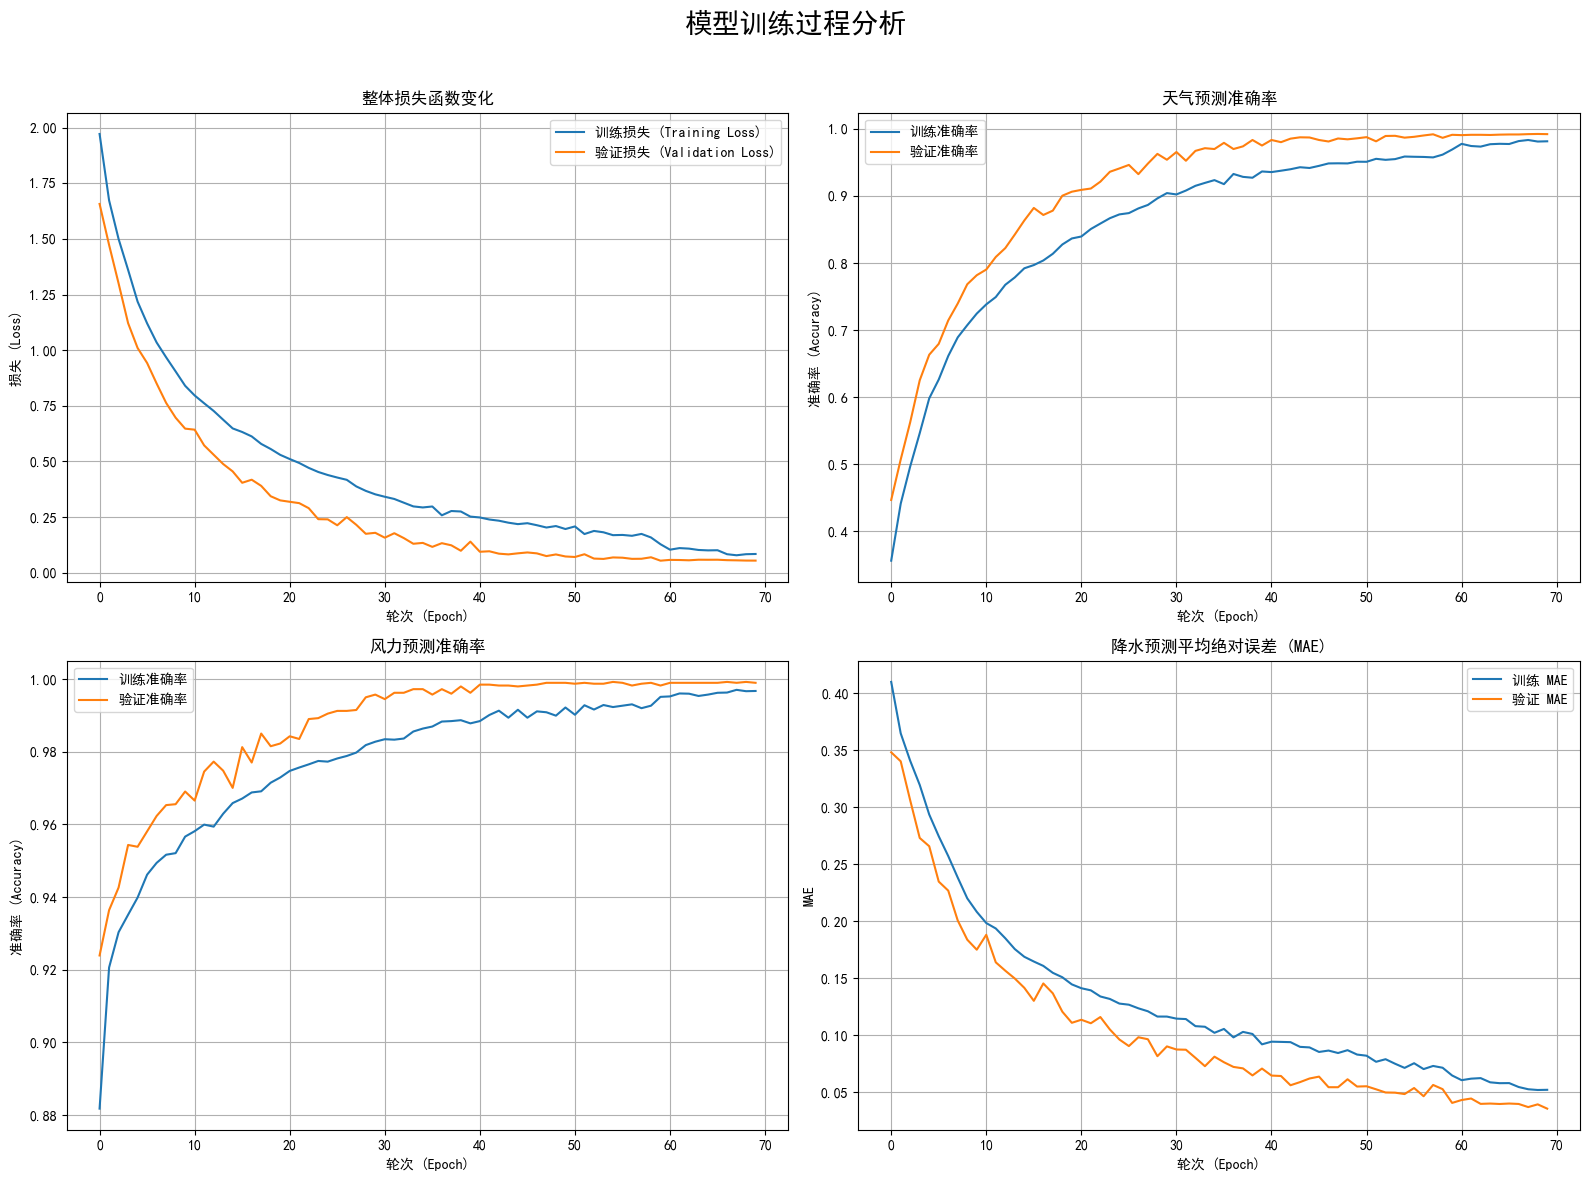


--- 2. 天气 预测性能分析 ---


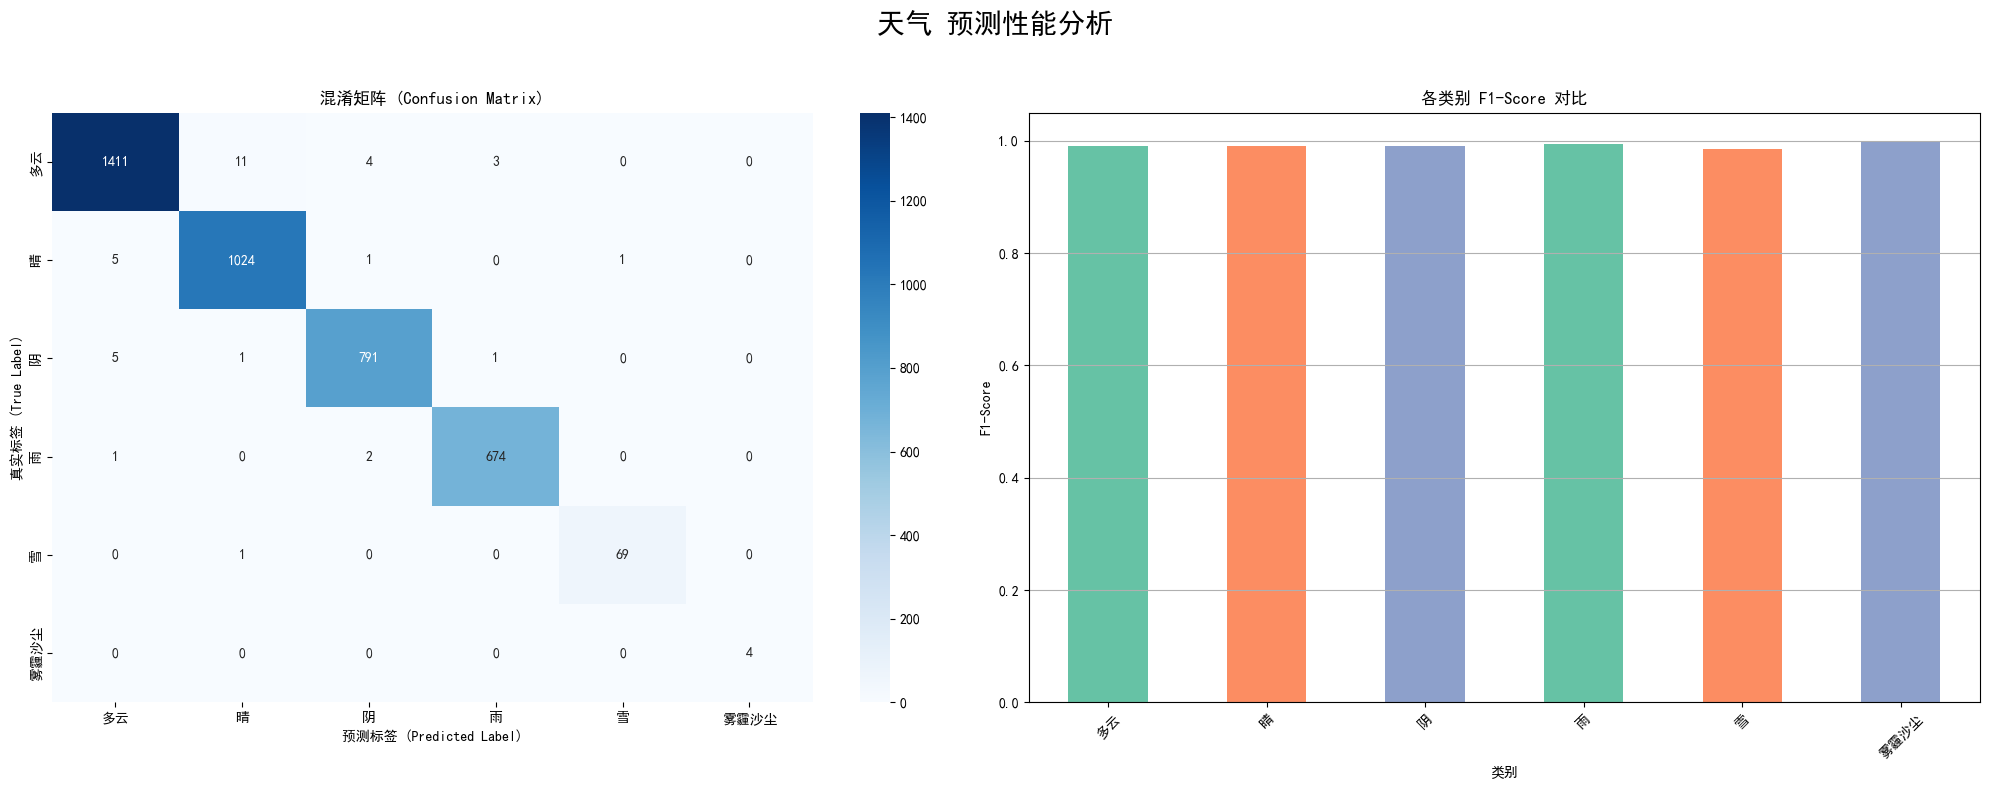


天气 分类报告详情:
              precision    recall  f1-score   support

          多云       0.99      0.99      0.99      1429
           晴       0.99      0.99      0.99      1031
           阴       0.99      0.99      0.99       798
           雨       0.99      1.00      0.99       677
           雪       0.99      0.99      0.99        70
        雾霾沙尘       1.00      1.00      1.00         4

    accuracy                           0.99      4009
   macro avg       0.99      0.99      0.99      4009
weighted avg       0.99      0.99      0.99      4009


--- 2. 风力等级 预测性能分析 ---


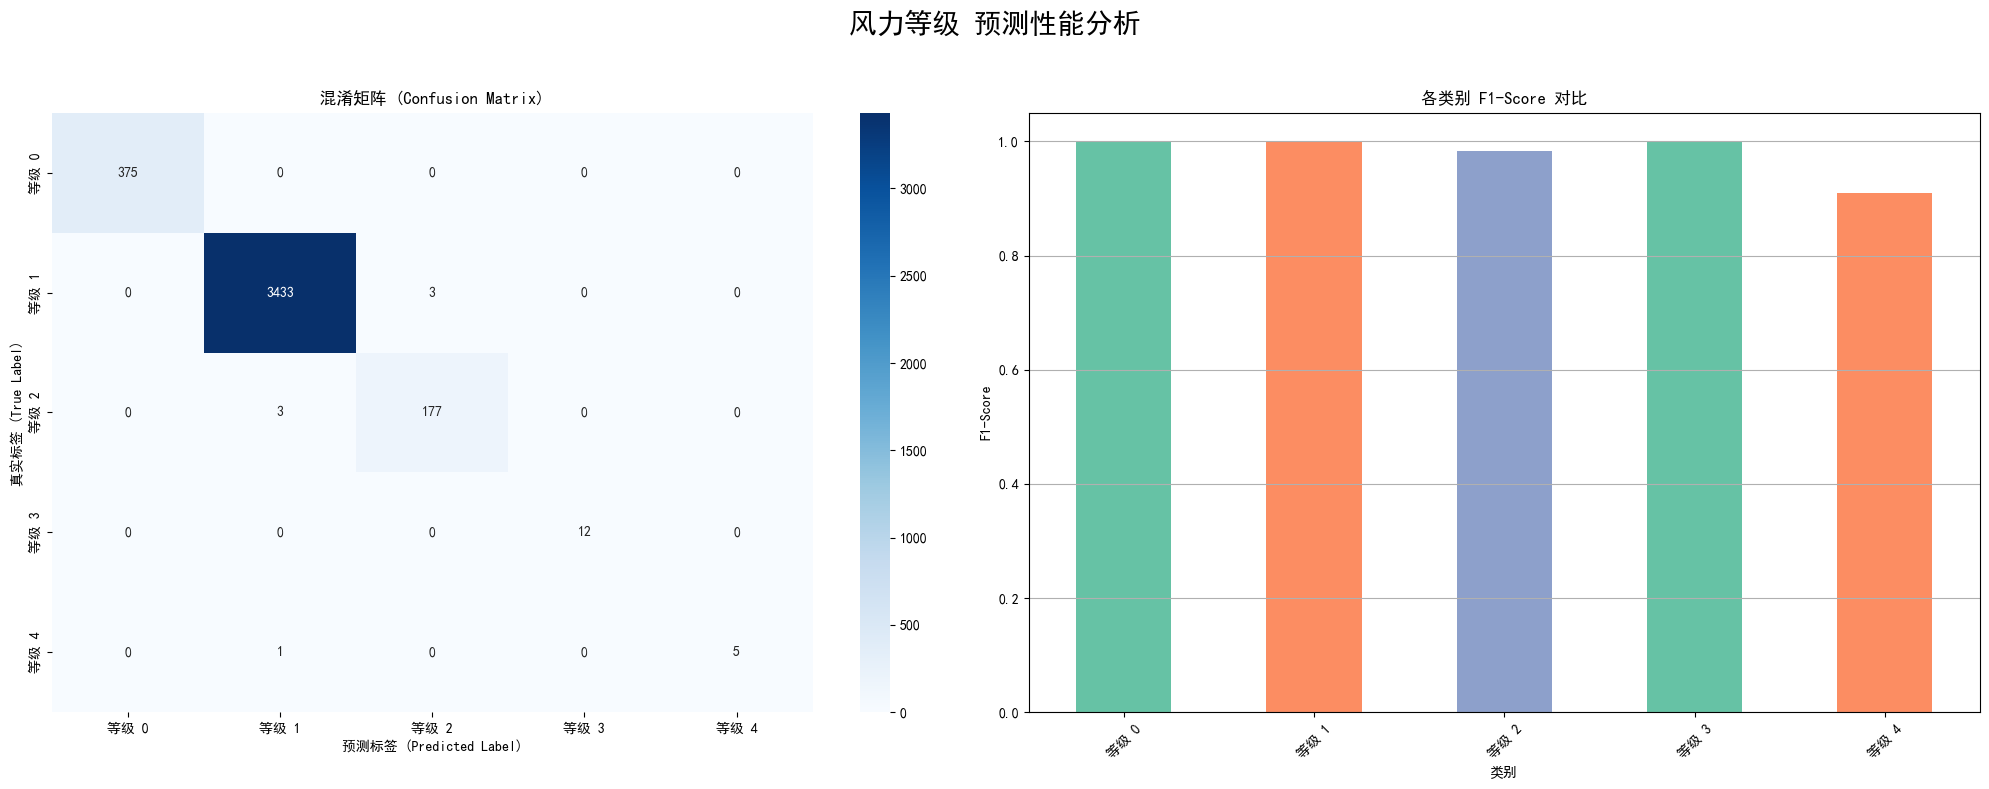


风力等级 分类报告详情:
              precision    recall  f1-score   support

        等级 0       1.00      1.00      1.00       375
        等级 1       1.00      1.00      1.00      3436
        等级 2       0.98      0.98      0.98       180
        等级 3       1.00      1.00      1.00        12
        等级 4       1.00      0.83      0.91         6

    accuracy                           1.00      4009
   macro avg       1.00      0.96      0.98      4009
weighted avg       1.00      1.00      1.00      4009


--- 3. 降水强度预测性能分析 ---


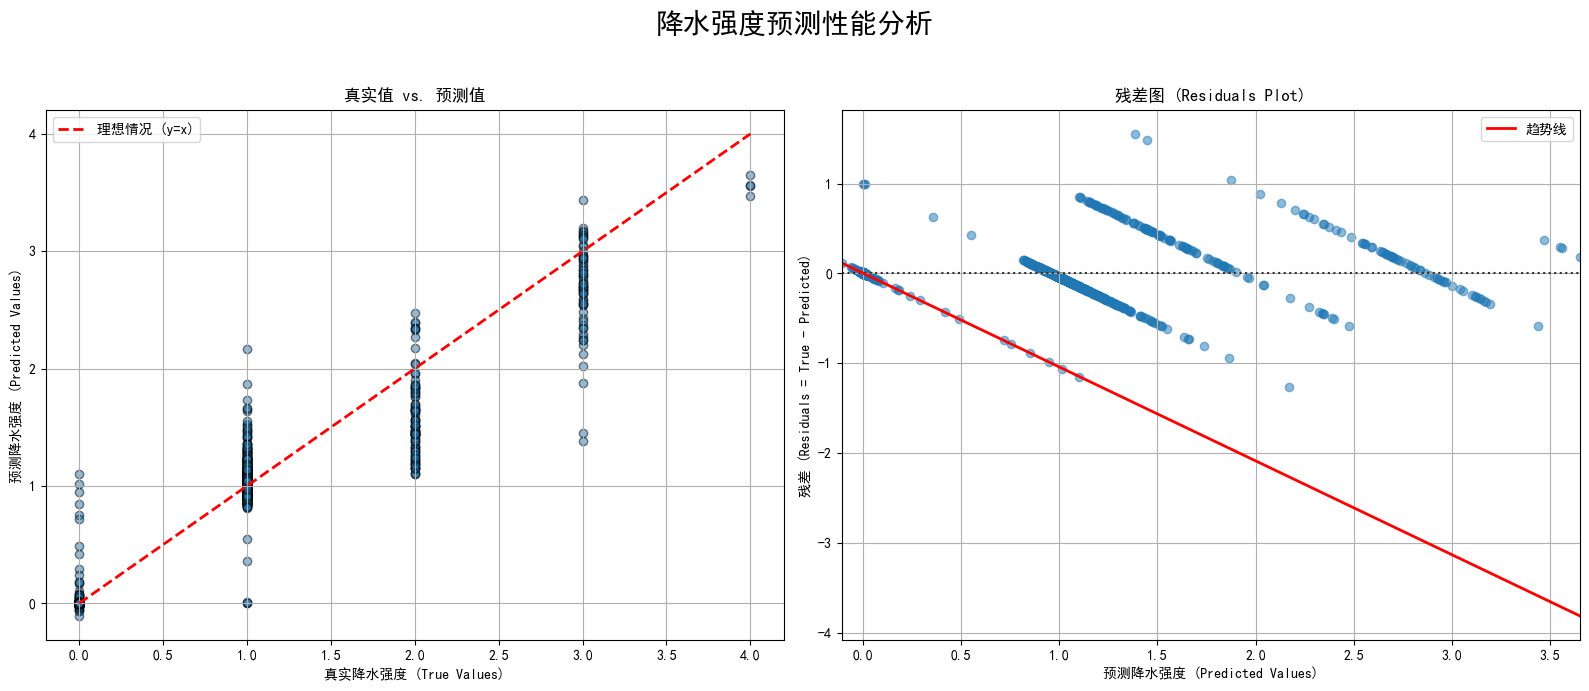


--- 4. 特征重要性分析 (Permutation Importance) ---
检测到序列模型(3D数据)，将使用手动实现的置换重要性分析。
注意: 此过程可能会非常耗时。
正在计算基准性能...
基准得分 (负总损失): -0.0534
正在置换特征 1/18: 纬度...
正在置换特征 2/18: 经度...
正在置换特征 3/18: SO2...
正在置换特征 4/18: NO2...
正在置换特征 5/18: PM10...
正在置换特征 6/18: 污染程度...
正在置换特征 7/18: 时间段...
正在置换特征 8/18: 气温...
正在置换特征 9/18: sin_月...
正在置换特征 10/18: cos_月...
正在置换特征 11/18: sin_日...
正在置换特征 12/18: cos_日...
正在置换特征 13/18: sin_星期...
正在置换特征 14/18: cos_星期...
正在置换特征 15/18: 污染物总和...
正在置换特征 16/18: 污染物比例_SO2...
正在置换特征 17/18: 污染物比例_NO2...
正在置换特征 18/18: 污染物比例_PM10...


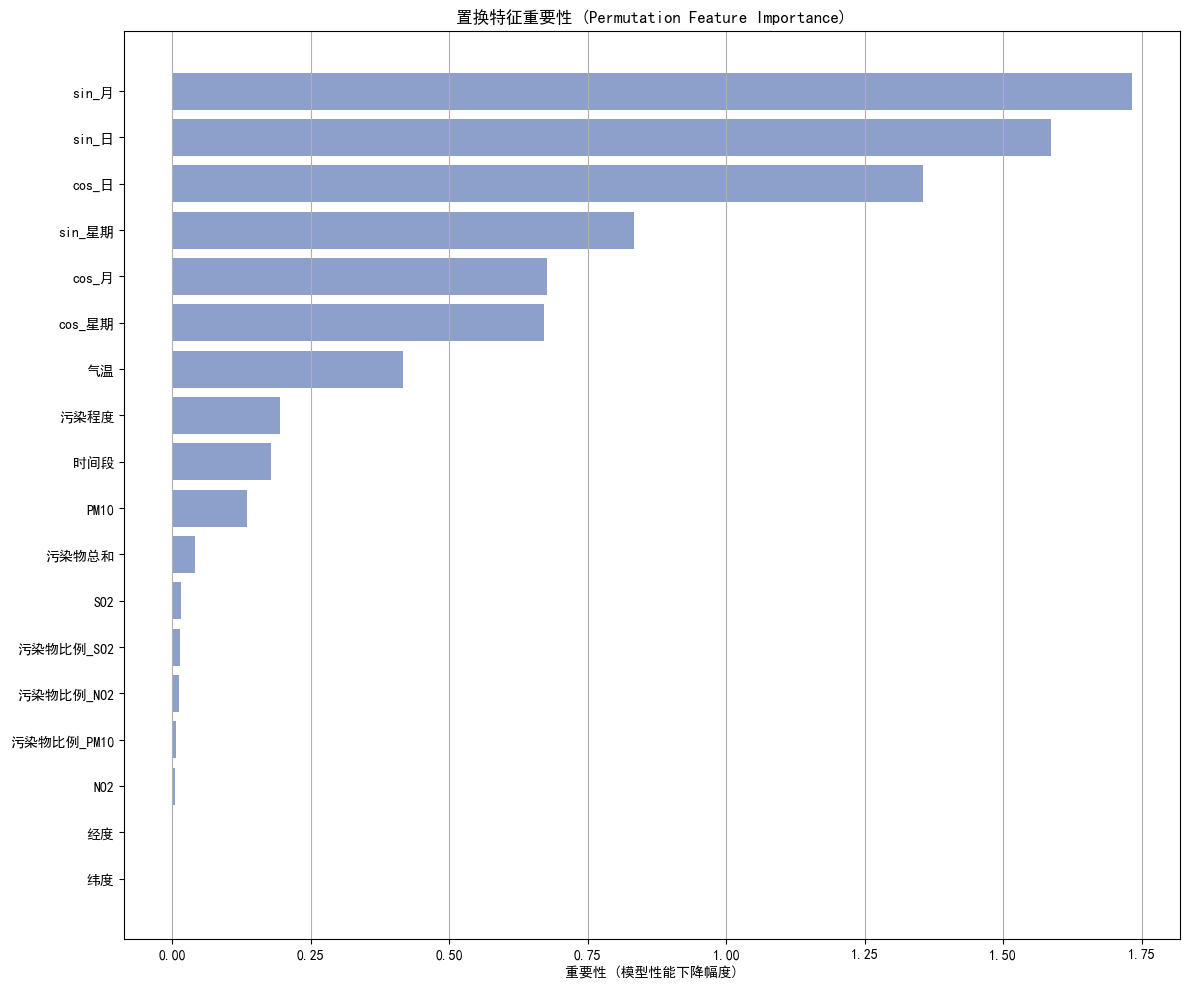



========================= 示例预测 =========================


In [4]:
# 使用示例
# =================================================================
#                      修正后的 main 函数
# =================================================================
def main():
    # 为了在matplotlib中正确显示中文，请确保这部分代码存在
    plt.rcParams['font.sans-serif'] = ['SimHei']  # 'SimHei' 是黑体，也可以是 'Microsoft YaHei'
    plt.rcParams['axes.unicode_minus'] = False    # 解决负号'-'显示为方块的问题

    # 创建预测器实例
    predictor = EnvironmentalPredictor()
    
    # 加载数据
    print("加载数据...")
    data = predictor.load_and_preprocess_data('end - 副本.csv')
    
    print(f"数据形状: {data.shape}")
    print(f"数据列: {data.columns.tolist()}")
    print(f"天气类别: {data['天气类别'].unique()}")
    print(f"数据日期范围: {data['日期'].min()} 到 {data['日期'].max()}")
    
    # 训练模型
    print("\n训练模型...")
    history, test_data, feature_names = None, None, None
    try:
        # --- (关键修正点) ---
        # 正确解包 train_models 返回的元组
        history, test_data, feature_names = predictor.train_models(data, use_sequences=True, sequence_length=12)
    except Exception as e:
        print(f"时序模型训练失败: {e}")
        print("切换到非时序模型...")
        # --- (关键修正点) ---
        # 同样需要解包
        history, test_data, feature_names = predictor.train_models(data, use_sequences=False)

    # 保存模型
    predictor.save_model('my_environment_model')
    
    # =================================================================
    #                      开始进行可视化分析 (使用新的Visualizer)
    # =================================================================
    if history and test_data:
        print("\n\n" + "="*25 + " 模型可视化分析 " + "="*25)
        # 1. 创建可视化分析器实例
        visualizer = ModelVisualizer(predictor, test_data, feature_names)
        
        # 2. 绘制所有分析图表 (调用 visualizer 的方法)
        visualizer.plot_training_history(history)
        
        # 分析天气预测
        visualizer.plot_classification_analysis(
            task_name="天气",
            true_labels=visualizer.weather_true_labels,
            pred_labels=visualizer.weather_pred_labels,
            class_names=visualizer.weather_class_names
        )
        
        # 分析风力预测 (假设风力编码为类别名称)
        wind_class_names = [f"等级 {i}" for i in range(max(visualizer.wind_true_labels) + 1)]
        visualizer.plot_classification_analysis(
            task_name="风力等级",
            true_labels=visualizer.wind_true_labels,
            pred_labels=visualizer.wind_pred_labels,
            class_names=wind_class_names
        )

        # 分析降水预测
        visualizer.plot_regression_analysis()

        # 分析特征重要性
        visualizer.plot_permutation_feature_importance()
        
    else:
        print("模型训练未成功，无法进行可视化分析。")


    # 示例预测部分保持不变
    print("\n\n" + "="*25 + " 示例预测 " + "="*25)
    if predictor.is_fitted and not predictor.use_sequences:
        sample_input = data.iloc[:1][feature_names].values
        predictions = predictor.predict(sample_input)
        print(f"预测天气: {predictions['weather']}")
        print(f"预测风力: {predictions['wind']}")
        print(f"预测降水强度: {predictions['rain']}")

if __name__ == "__main__":
    main()
